In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spotify_top_1000_tracks.csv to spotify_top_1000_tracks.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Gavin Idrish Bolanos"
student_id = "20250722"  # Replace with your actual ID

id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

In [ ]:
import pandas as pd

df = pd.read_csv("spotify_top_1000_tracks.csv")  # change this to your actual filename
df.head()

,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433


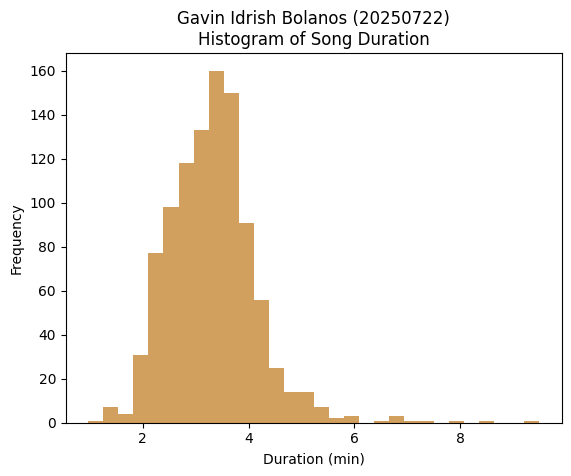

In [ ]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)

plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')

plt.show()

/tmp/ipykernel_9987/1294308594.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


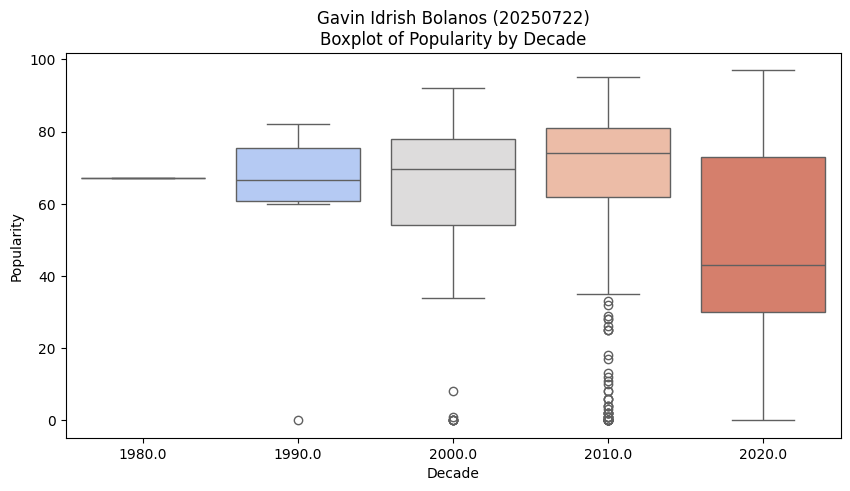

In [ ]:
# make sure dates are parsed safely
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# extract year
df['year'] = df['release_date'].dt.year

# create decade
df['decade'] = (df['year'] // 10) * 10

# plot
plt.figure(figsize=(10,5))

sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')

plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.xlabel("Decade")
plt.ylabel("Popularity")

plt.show()

/tmp/ipykernel_9987/4099255378.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


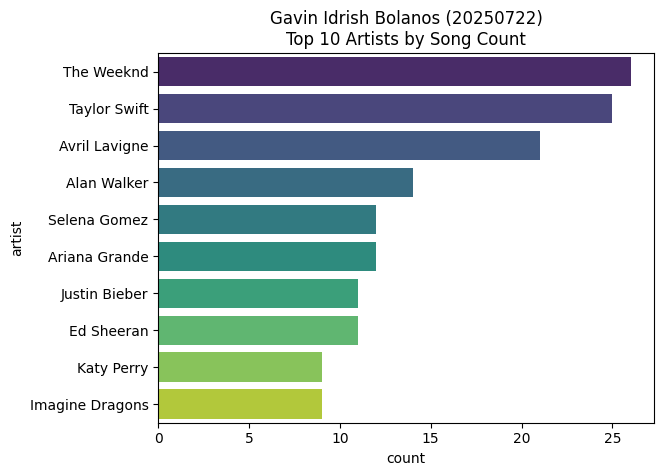

In [ ]:
sns.countplot(
    y='artist',
    data=df,
    order=df['artist'].value_counts().head(10).index,
    palette='viridis'
)

plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

/tmp/ipykernel_9987/1165256031.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_9987/1165256031.py:1: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


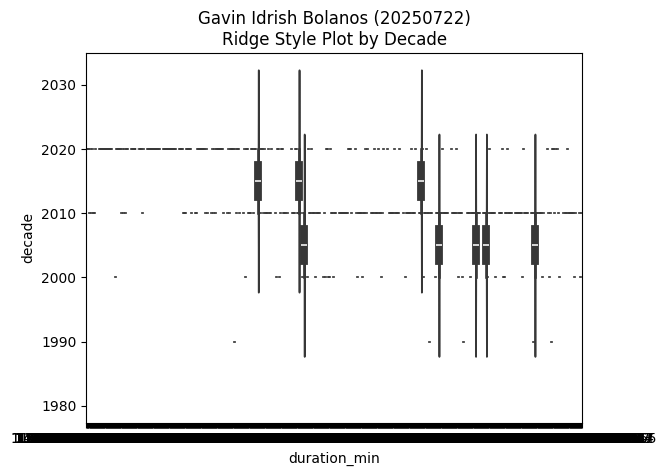

In [ ]:
sns.violinplot(
    data=df,
    x='duration_min',
    y='decade',
    palette='coolwarm',
    scale='width'
)

plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()

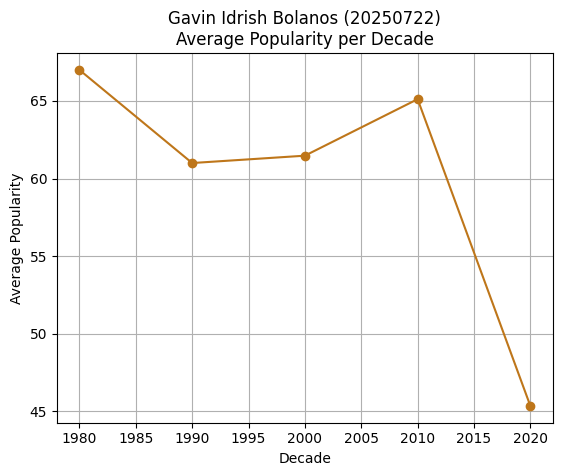

In [ ]:
avg_pop = df.groupby('decade')['popularity'].mean()

avg_pop.plot(kind='line', color=color1, marker='o')

plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')

plt.grid(True)
plt.show()

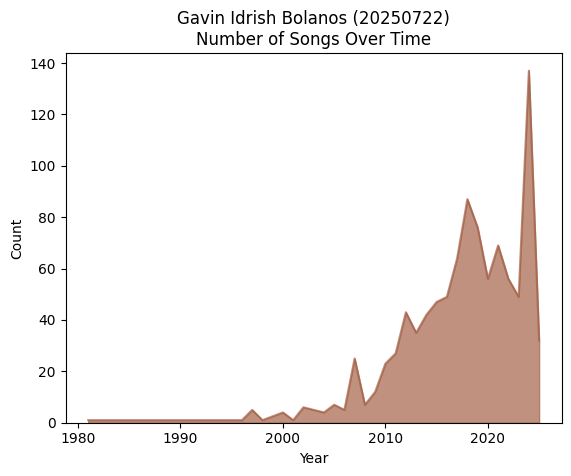

In [ ]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

count_by_year = df['release_year'].value_counts().sort_index()

count_by_year.plot(kind='area', color=color2, alpha=0.7)

plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

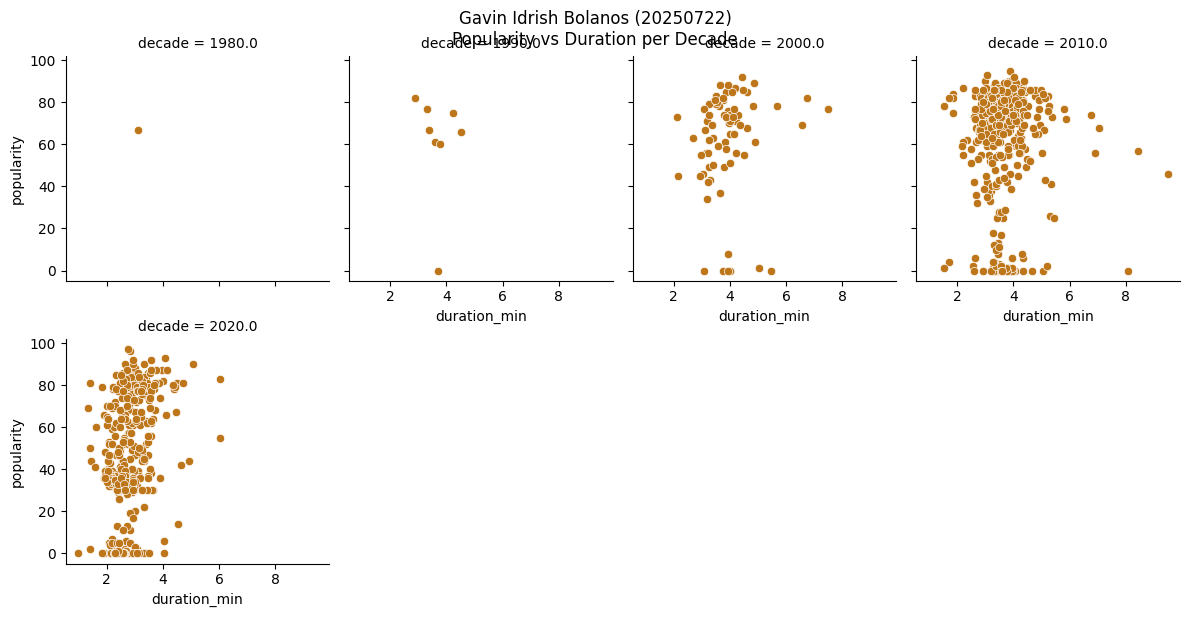

In [ ]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)

g.map_dataframe(
    sns.scatterplot,
    x='duration_min',
    y='popularity',
    color=color1
)

g.fig.suptitle(
    f"{student_name} ({student_id})\nPopularity vs Duration per Decade",
    y=1.02
)

plt.show()

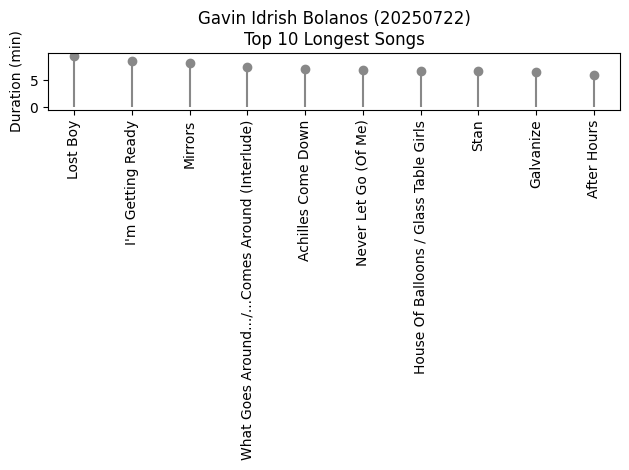

In [ ]:
longest = df.nlargest(10, 'duration_min')

plt.stem(
    longest['track_name'],
    longest['duration_min'],
    linefmt='#888888',
    markerfmt='o',
    basefmt=" "
)

plt.xticks(rotation=90)

plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')

plt.tight_layout()
plt.show()

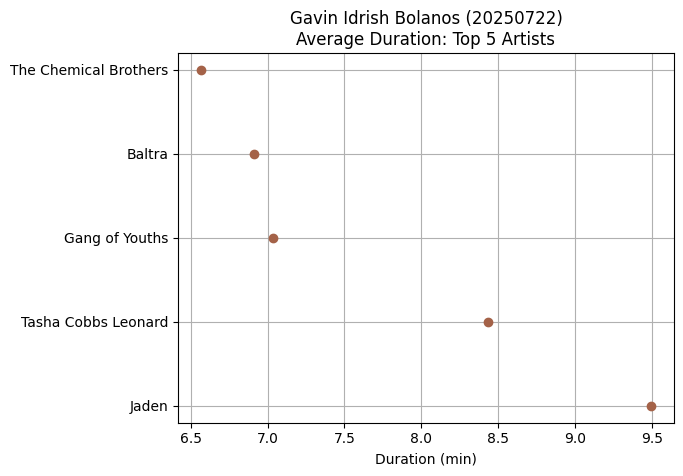

In [ ]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)

plt.plot(
    avg_duration.values,
    avg_duration.index,
    'o',
    color=color2
)

plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)

plt.show()

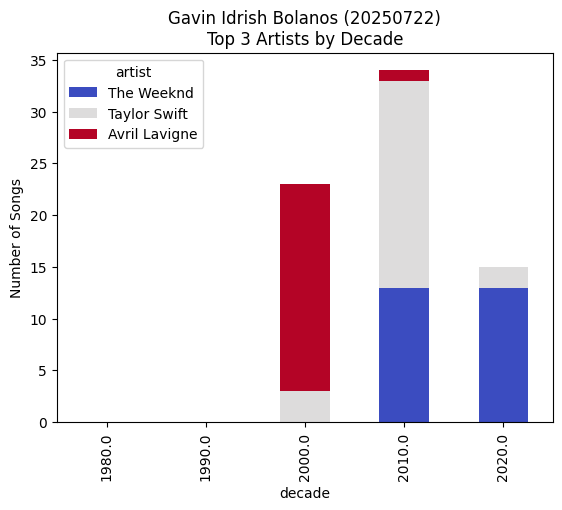

In [ ]:
crosstab = pd.crosstab(df['decade'], df['artist'])

top3 = df['artist'].value_counts().head(3).index

crosstab[top3].plot(
    kind='bar',
    stacked=True,
    colormap='coolwarm'
)

plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')

plt.show()

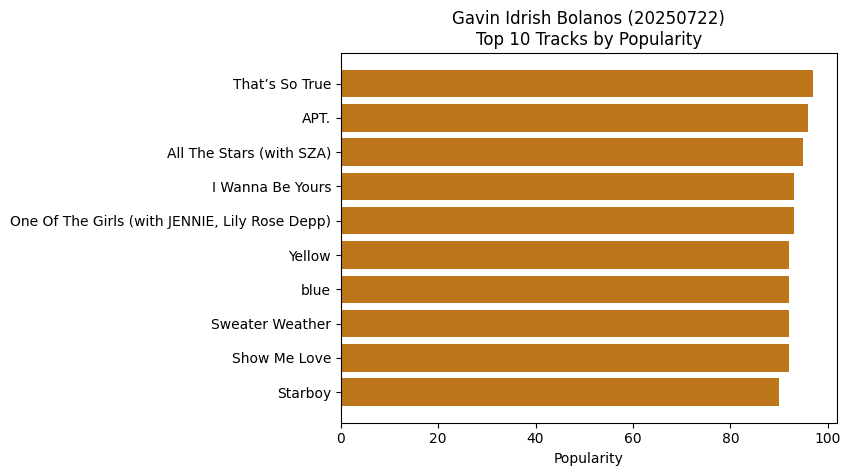

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("spotify_top_1000_tracks.csv") # Ensure df is defined

top_tracks = df.nlargest(10, 'popularity')

plt.barh(
    top_tracks['track_name'],
    top_tracks['popularity'],
    color=color1
)

plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()

/tmp/ipykernel_3095/443572256.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_3095/443572256.py:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


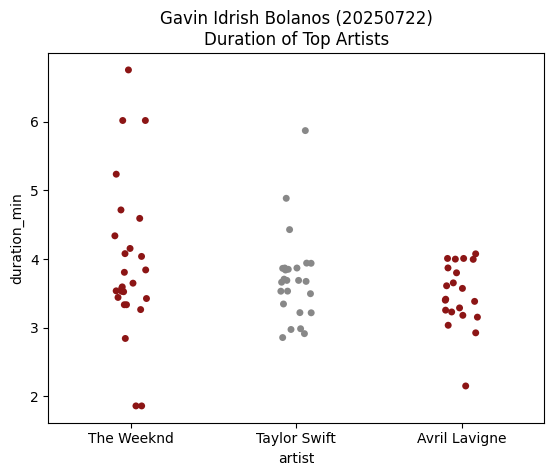

In [ ]:
# Get top 3 artists
top_artists = df['artist'].value_counts().head(3).index

# Plot
sns.stripplot(
    data=df[df['artist'].isin(top_artists)],
    x='artist',
    y='duration_min',
    palette=['#8C1515', '#888888']
)

plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()

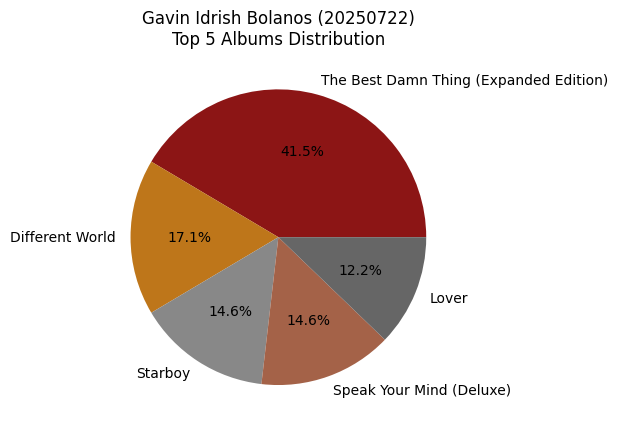

In [ ]:
top_albums = df['album'].value_counts().head(5)

colors = ['#8C1515', color1, '#888888', color2, '#666666']

plt.pie(
    top_albums,
    labels=top_albums.index,
    autopct='%1.1f%%',
    colors=colors
)

plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

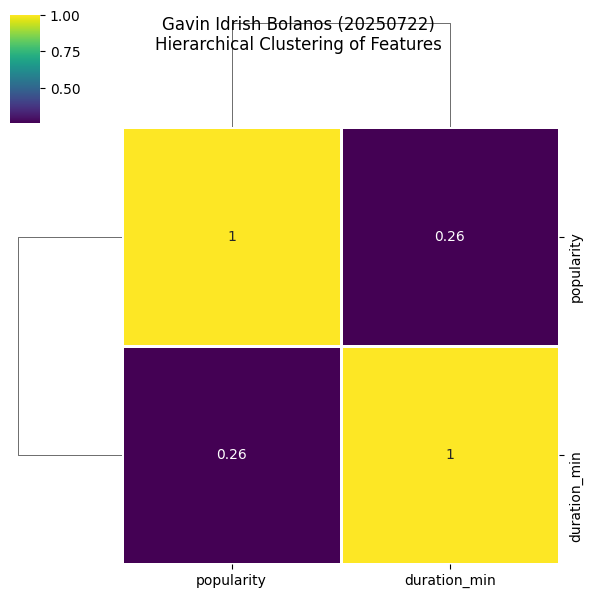

In [ ]:
numerical_cols = ['popularity', 'duration_min']

df_numeric = df[numerical_cols].dropna()

sns.clustermap(
    df_numeric.corr(),
    annot=True,
    cmap='viridis',
    linewidths=.75,
    figsize=(6, 6)
)

plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features")
plt.show()

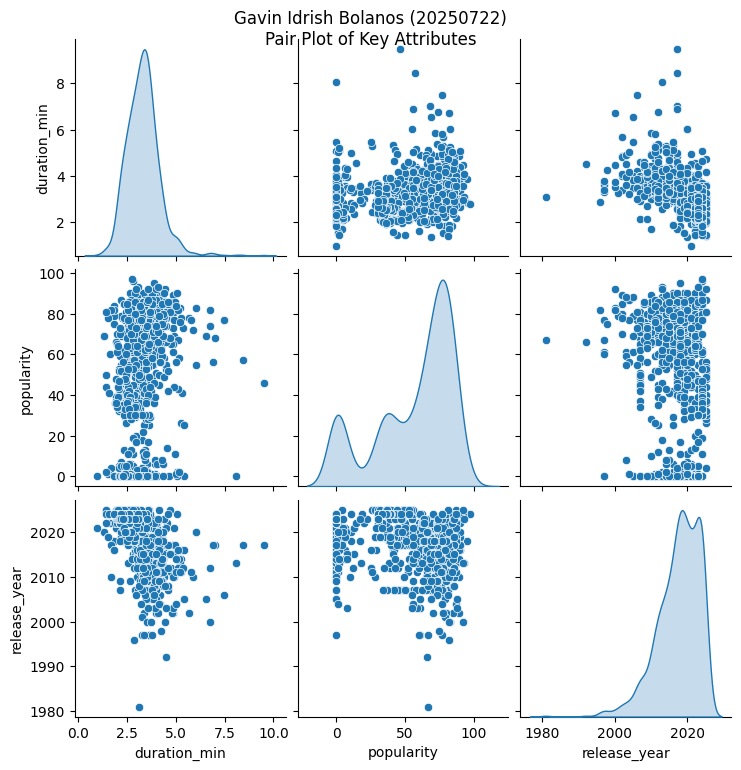

In [ ]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
sns.pairplot(
    df[['duration_min', 'popularity', 'release_year']],
    diag_kind='kde'
)

plt.suptitle(
    f"{student_name} ({student_id})\nPair Plot of Key Attributes",
    y=1.02
)

plt.show()

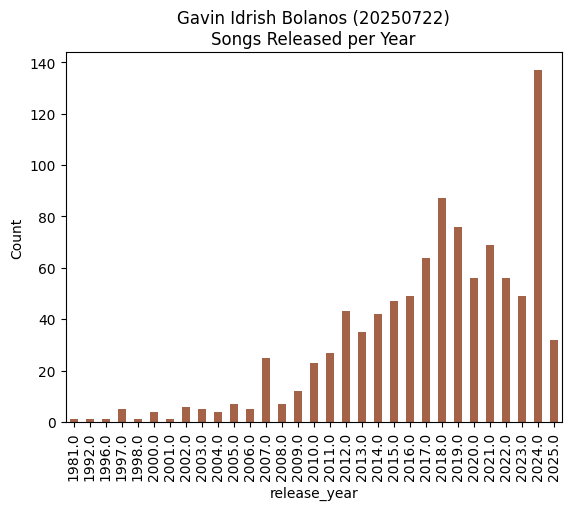

In [ ]:
df['release_year'].value_counts().sort_index().plot(
    kind='bar',
    color=color2
)

plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')

plt.show()

/tmp/ipykernel_3095/3309482531.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


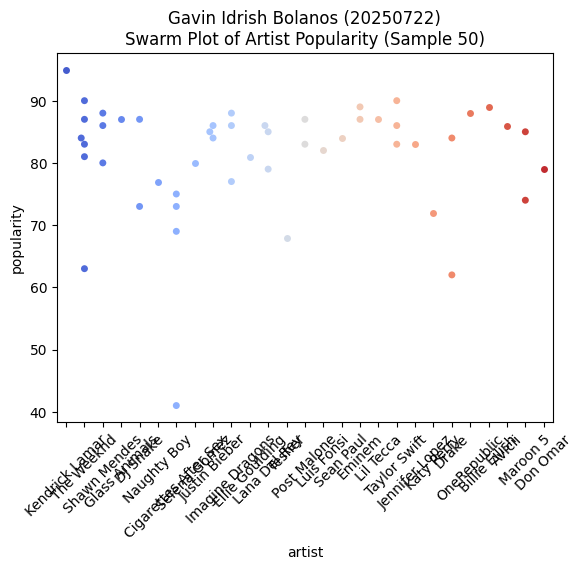

In [ ]:
sns.swarmplot(
    data=df.head(50),
    x='artist',
    y='popularity',
    palette='coolwarm'
)

plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45)

plt.show()

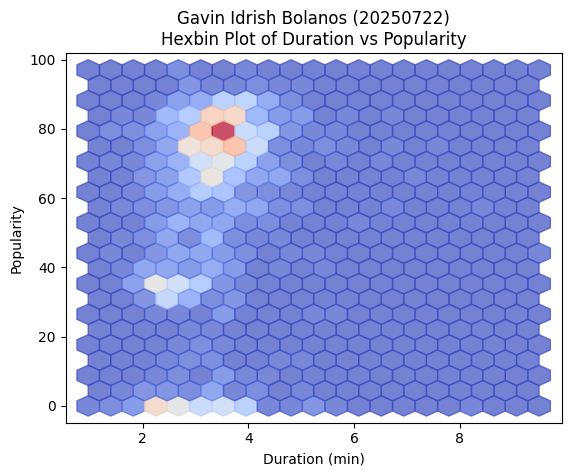

In [ ]:
plt.hexbin(
    df['duration_min'],
    df['popularity'],
    gridsize=20,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel('Duration (min)')
plt.ylabel('Popularity')

plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")

plt.show()

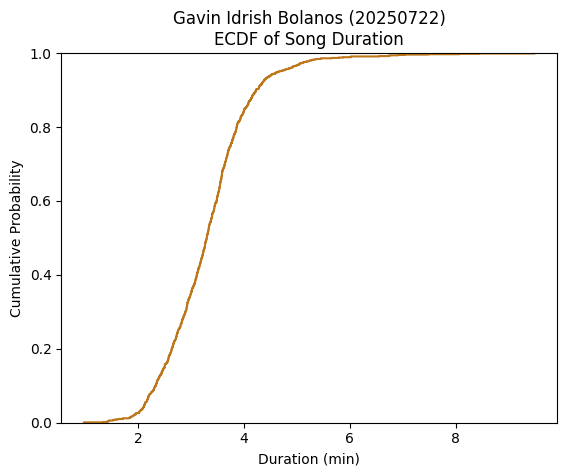

In [ ]:
sns.ecdfplot(
    data=df,
    x='duration_min',
    color=color1
)

plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')

plt.show()

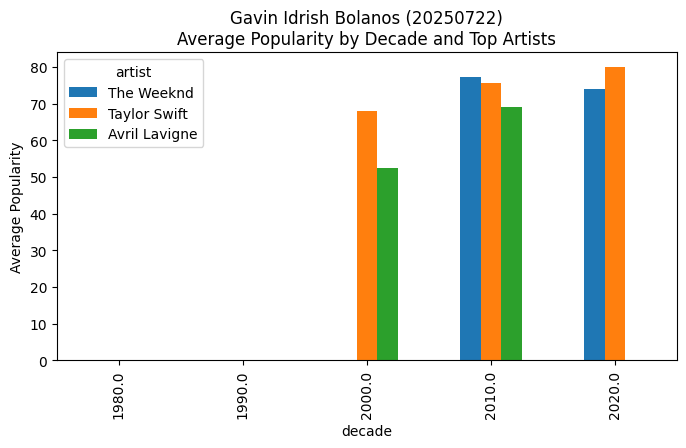

In [ ]:
import matplotlib.pyplot as plt

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df['decade'] = (df['year'] // 10) * 10

avg_artist_decade = (
    df.groupby(['decade', 'artist'])['popularity']
    .mean()
    .unstack()
    .fillna(0)
)

top3 = df['artist'].value_counts().head(3).index

avg_artist_decade[top3].plot(
    kind='bar',
    figsize=(8, 4)
)

plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')

plt.show()

                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

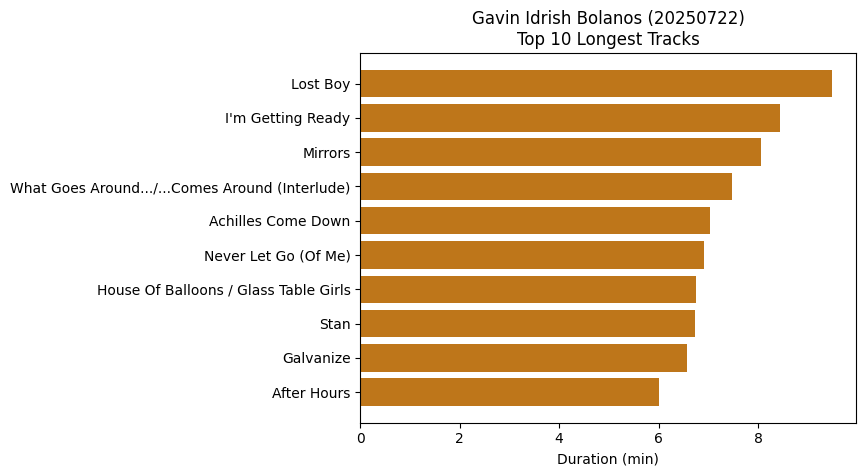

In [ ]:
# Top 10 longest tracks
longest_tracks = df.nlargest(10, 'duration_min')[['track_name', 'artist', 'duration_min']]

print(longest_tracks)

# Plot
longest_tracks = longest_tracks.sort_values('duration_min')

color_bar = color1 # Define color_bar

plt.barh(
    longest_tracks['track_name'],
    longest_tracks['duration_min'],
    color=color_bar
)

plt.xlabel('Duration (min)')
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Tracks")
plt.show()

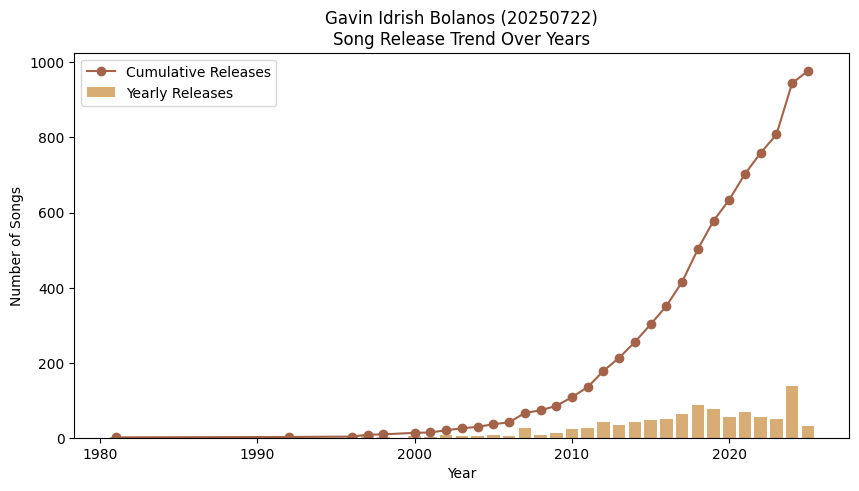

In [ ]:
yearly_counts = df['year'].value_counts().sort_index()

# Cumulative counts
cumulative_counts = yearly_counts.cumsum()

# Plot
plt.figure(figsize=(10, 5))

# Bar plot (yearly)
plt.bar(
    yearly_counts.index,
    yearly_counts.values,
    color=color1,
    alpha=0.6,
    label='Yearly Releases'
)

# Line plot (cumulative)
plt.plot(
    cumulative_counts.index,
    cumulative_counts.values,
    color=color2,
    marker='o',
    label='Cumulative Releases'
)

plt.title(f"{student_name} ({student_id})\nSong Release Trend Over Years")
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.legend()
plt.show()

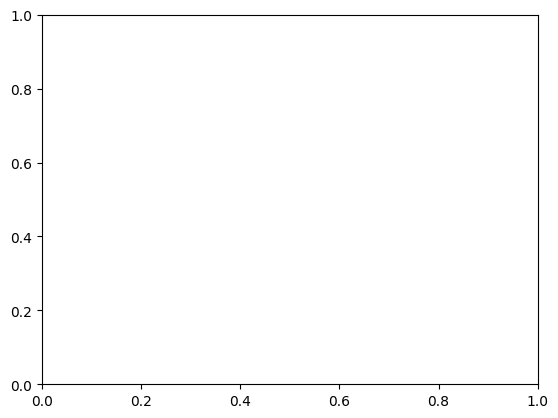

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()

years = sorted(df['year'].unique())

def update(year):
    ax.clear()
    data = df[df['year'] == year]

    ax.hexbin(
        data['duration_min'],
        data['popularity'],
        gridsize=20,
        cmap=cmap_color,
        alpha=0.7
    )

    ax.set_title(f"{student_name} ({student_id})\nYear: {year}")
    ax.set_xlabel('Duration (min)')
    ax.set_ylabel('Popularity')

ani = animation.FuncAnimation(fig, update, frames=years, interval=800)

plt.show()